# Models trained to output a 4Hz signal



In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

2025-09-26 09:22:08.385040: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-26 09:22:08.393497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-26 09:22:08.402980: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-26 09:22:08.405740: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-26 09:22:08.413324: I tensorflow/core/platform/cpu_feature_guar

## get list of trained models

In [3]:
# lfp models (lfp) — theta 4.0

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_target_models/models/xor/phase/P_rec_0.2_Taus_4.0_25.0'
lfp_theta4_model_list = ld.find_files_keywords(lfp_model_dir, ['4.0', '.mat'])
# remove ones in the "old" folder
lfp_theta4_model_list = [m for m in lfp_theta4_model_list if 'old' not in m]
# remove directories 
lfp_theta4_model_list = [m.split('/')[-1] for m in lfp_theta4_model_list]
lfp_theta4_model_list.sort()

print(lfp_theta4_model_list)
print(len(lfp_theta4_model_list))

losses = []
train_trials = []
for i, model_name in enumerate(lfp_theta4_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    # perfs.append(model_data['eval_perf_mean'][0][0])
    losses.append(model_data['losses'][0][-1])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Final test loss: {losses[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_004442.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_011448.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_011452.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_011702.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_011828.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012029.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012121.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012300.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012503.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012633.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012650.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_012753.mat', 'Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_013118.mat']
13
Model: Task_xor_N_200_Jitter_10_50_LFPdelay_4.0_2025_09_26_004442.mat, Final test loss: 0.0, Train trials: 5401
Model: Task_xor_N_200_Jitt

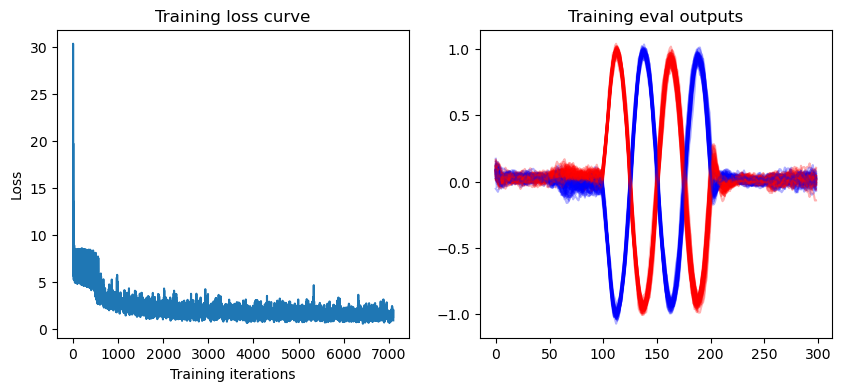

In [4]:
fig, axs = plt.subplots(1,2, figsize=(10,4))
model_tr = model_data['tr'][0][0]
axs[0].plot(range(model_tr),model_data['losses'][0][:model_tr])
axs[0].set_xlabel('Training iterations')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training loss curve')

labels = model_data['eval_labels'][0]
plot_colors = ['r' if l==1 else 'b' for l in labels]
for i, pc in enumerate(plot_colors):
    axs[1].plot(model_data['eval_os'][i,:], color=pc, alpha=0.3)
# axs[1].plot(model_data['eval_os'].T)
axs[1].set_title('Training eval outputs')
plt.show()

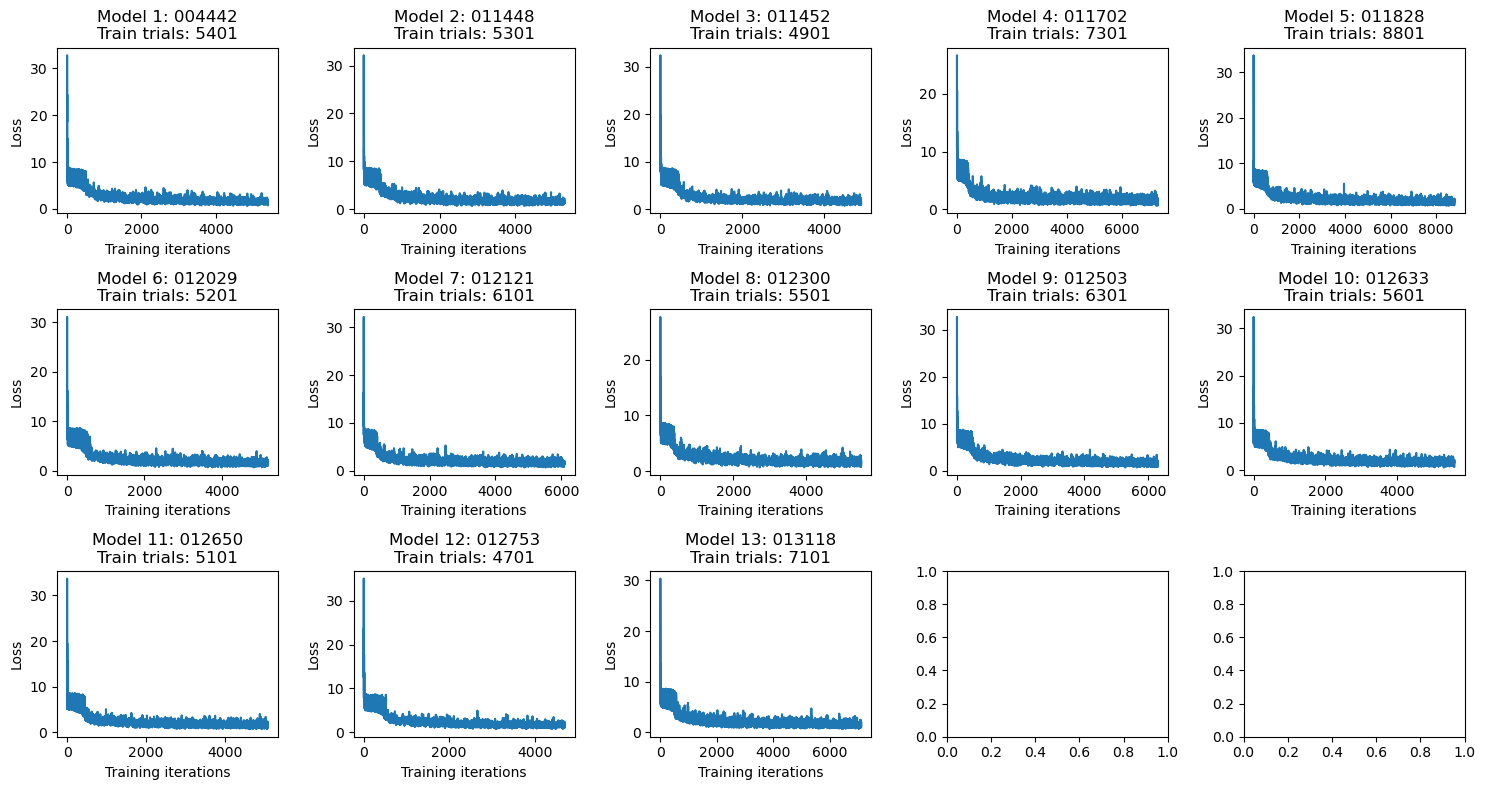

In [11]:
# plot all training curves

fig, axs = plt.subplots(3,5, figsize=(15,8))

for i, model_name in enumerate(lfp_theta4_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    model_tr = model_data['tr'][0][0]
    ax = axs[i//5, i%5]
    ax.plot(range(model_tr),model_data['losses'][0][:model_tr])
    ax.set_title(f'Model {i+1}: {model_name[-10:-4]}\nTrain trials: {model_tr}')
    ax.set_xlabel('Training iterations')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

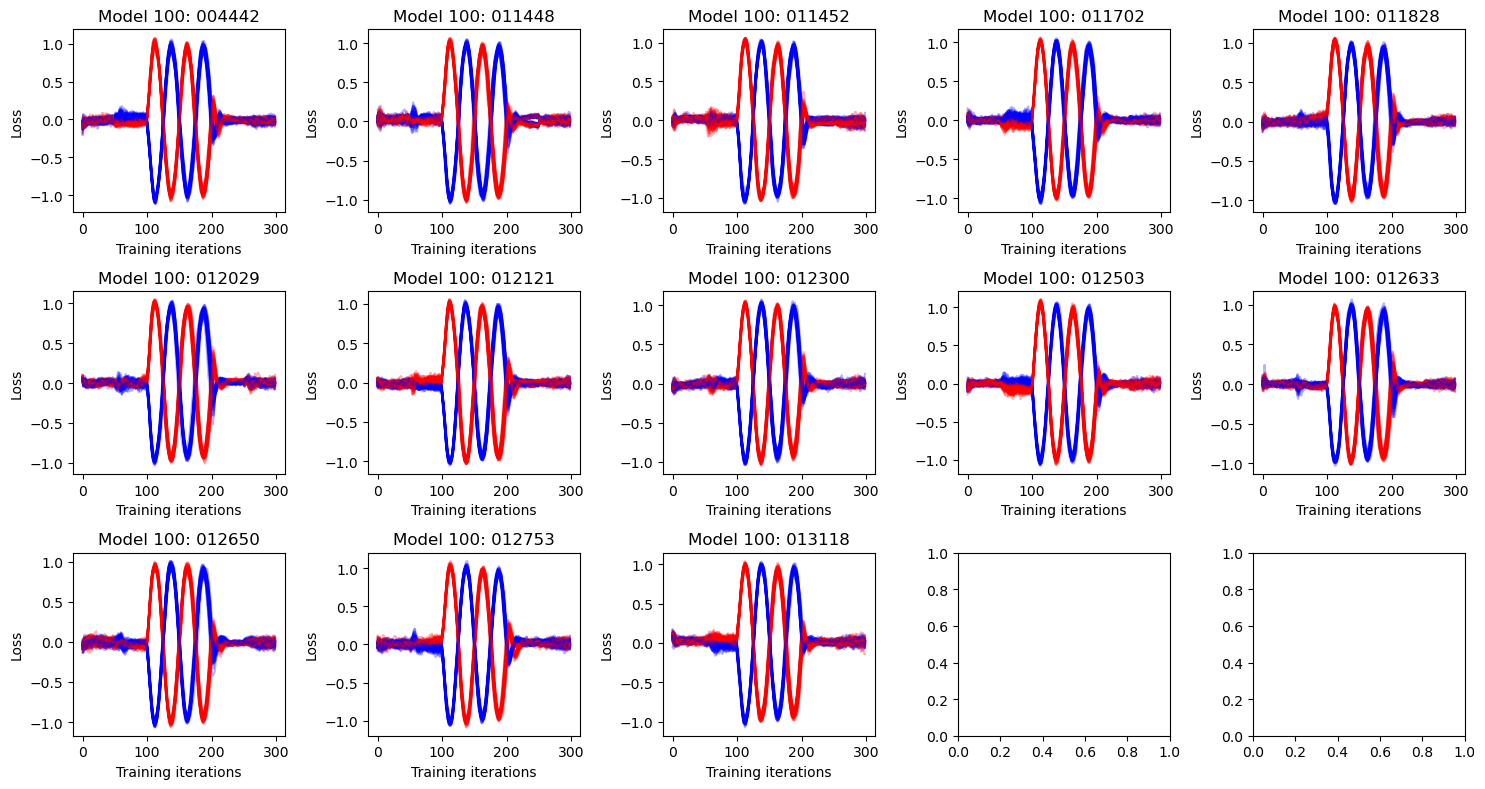

In [13]:
# plot all eval outputs

fig, axs = plt.subplots(3,5, figsize=(15,8))

for i, model_name in enumerate(lfp_theta4_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    ax = axs[i//5, i%5]
    labels = model_data['eval_labels'][0]
    plot_colors = ['r' if l==1 else 'b' for l in labels]
    for i, pc in enumerate(plot_colors):
        ax.plot(model_data['eval_os'][i,:], color=pc, alpha=0.3)
    ax.set_title(f'Model {i+1}: {model_name[-10:-4]}')
    ax.set_xlabel('Training iterations')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

In [14]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model_lfp
from model_lfp import generate_input_stim_xor

Instructions for updating:
non-resource variables are not supported in the long term


## study models

### extend maintenance

#### delay=400

In [15]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

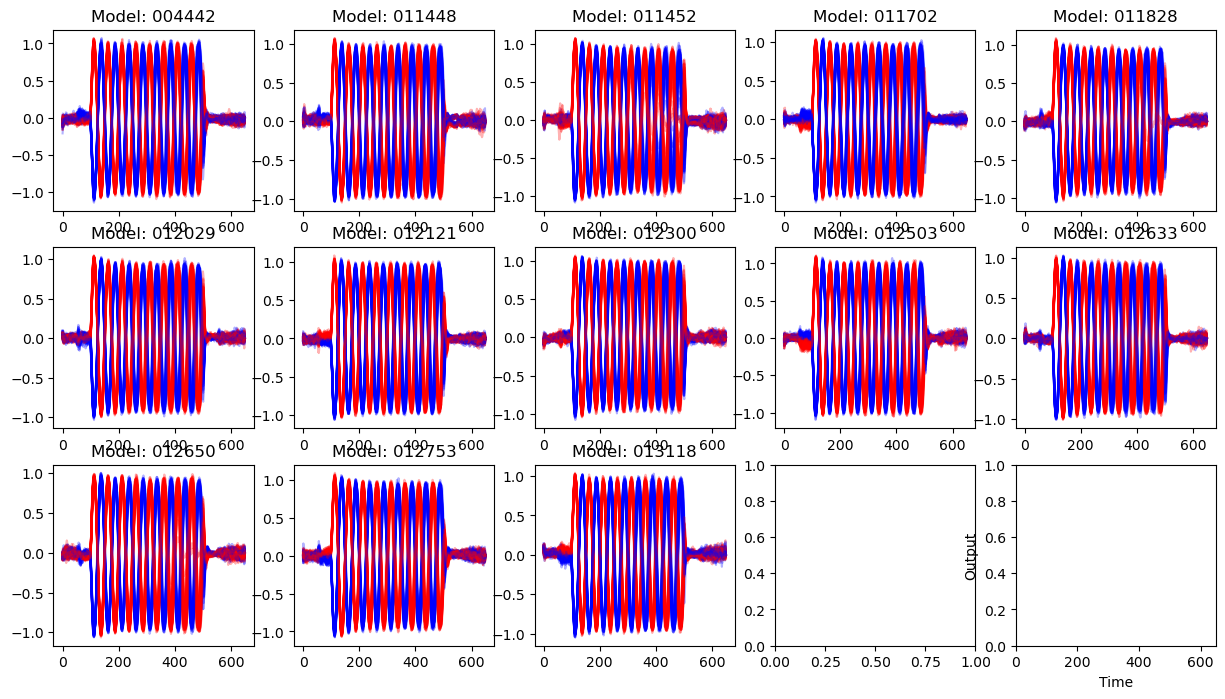

In [16]:
# model eval on 100 random trials — LFP theta 4.0; delay=50, jitter=10 

n_trials = 100

model_dir = lfp_model_dir
model_list = lfp_theta4_model_list

fig, axs = plt.subplots(3,5, figsize=(15,8))
axs = axs.flatten()

lfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model_lfp.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 1:
            axs[n_model].plot(eval_o, color='r', alpha=0.3)
        else:
            axs[n_model].plot(eval_o, color='b', alpha=0.3)

    axs[n_model].set_title(f'Model: {model_name[-10:-4]}')
    plt.xlabel('Time')
    plt.ylabel('Output')
    plt.xlim(0, settings['T'])
    # plt.ylim(-1, 1)
plt.show()


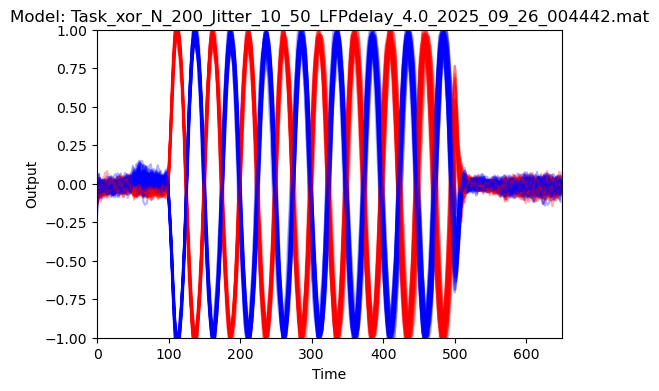

In [ ]:
# model eval on 100 random trials — LFP theta 4.0; delay=100, jitter=50 

n_trials = 100

model_dir = lfp_model_dir
model_list = lfp_theta4_model_list

lfp_model_perfs = np.zeros(len(model_list))

model_name = model_list[2]

plt.figure(figsize=(6,4))
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model_lfp.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 1:
        plt.plot(eval_o, color='r', alpha=0.3)
    else:
        plt.plot(eval_o, color='b', alpha=0.3)

plt.title(f'Model: {model_name}')
plt.xlabel('Time')
plt.ylabel('Output')
plt.xlim(0, settings['T'])
plt.ylim(-1, 1)
plt.show()


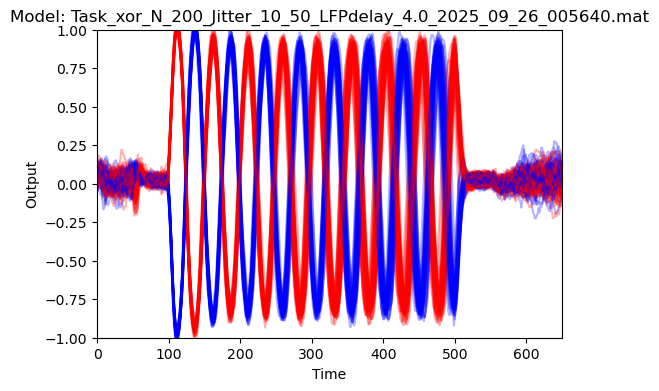

In [14]:
# model eval on 100 random trials — LFP theta 4.0; delay=100, jitter=50 

n_trials = 100

model_dir = lfp_model_dir
model_list = lfp_theta4_model_list

lfp_model_perfs = np.zeros(len(model_list))

model_name = model_list[3]

plt.figure(figsize=(6,4))
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model_lfp.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 1:
        plt.plot(eval_o, color='r', alpha=0.3)
    else:
        plt.plot(eval_o, color='b', alpha=0.3)

plt.title(f'Model: {model_name}')
plt.xlabel('Time')
plt.ylabel('Output')
plt.xlim(0, settings['T'])
plt.ylim(-1, 1)
plt.show()


## generate data

In [5]:
import pickle as pk

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

In [6]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [7]:
# delay150
settings = {
        'T': 400, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [7]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# delay400 -- longer pre-trial period - haven't run yet
settings = {
        'T': 700, # trial duration (in steps)
        'stim_on': 100, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

### generate delay=400 data

In [ ]:
# for LFP models - theta4

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta4_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }


for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                lfp_stim = generate_LFP_input(settings)
                u = np.vstack((u, lfp_stim)) # shape (3, T
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_124353/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_125136/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_125229/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_130240/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_130531/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0

In [10]:
# for LFP models - theta8

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta8_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [8], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                lfp_stim = generate_LFP_input(settings)
                u = np.vstack((u, lfp_stim)) # shape (3, T
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_141802/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_144024/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_144534/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_145313/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_150646/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0

### now data with no sine wave

In [9]:
# for LFP models - theta4, NO LFP

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta4_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }


for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_nolfp.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_nolfp.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                # lfp_stim = generate_LFP_input(settings)
                lfp_stim = np.zeros((1, settings['T'])) # no LFP input
                u = np.vstack((u, lfp_stim)) # shape (3, T
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_nolfp.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_nolfp.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_124353/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_125136/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_125229/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_130240/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_16_130531/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0

In [10]:
# for LFP models - theta8, NO LFP

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta8_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [8], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_nolfp.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_nolfp.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                # lfp_stim = generate_LFP_input(settings)
                lfp_stim = np.zeros((1, settings['T'])) # no LFP input
                u = np.vstack((u, lfp_stim)) # shape (3, T)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_nolfp.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_nolfp.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_141802/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_144024/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_144534/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_145313/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_150646/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_8.0

In [ ]:
# for non-LFP models

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = xlfp_model_dir
model_list = xlfp_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, 'neural_dict.pkl')) and os.path.exists(os.path.join(output_dir, 'bhv_dict.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124351/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124357/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124459/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_125248/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_125609/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_130506

### generate data with w manipulations

In [ ]:
# not actually using this, but here for reference
def lesion_ww_matrix(W, exc_ind, inh_ind, lesion_perc, connection_type='ii'):
    
    if connection_type.lower() == 'ii':  # Inh -> Inh
        W[np.ix_(inh_ind, inh_ind)] *= lesion_perc
    elif connection_type.lower() == 'ie':  # Exc -> Inh
        W[np.ix_(inh_ind, exc_ind)] *= lesion_perc
    elif connection_type.lower() == 'ei':  # Inh -> Exc
        W[np.ix_(exc_ind, inh_ind)] *= lesion_perc
    elif connection_type.lower() == 'ee':  # Exc -> Exc
        W[np.ix_(exc_ind, exc_ind)] *= lesion_perc
    
    return W

In [ ]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# for LFP models; lesion ii by 130%

import importlib
importlib.reload(model)

lesion_type = 'ii'  # Inh -> Inh
lesion_perc = 130

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                # _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)
                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, 
                                              u=u, lesion=lesion_type, lesion_perc=lesion_perc*0.01, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309/
✔ Saved model outputs 

In [ ]:
# for LFP models; lesion ii by 50%

import importlib
importlib.reload(model)

lesion_type = 'ii'  # Inh -> Inh
lesion_perc = 50

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                # _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)
                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, 
                                              u=u, lesion=lesion_type, lesion_perc=lesion_perc*0.01, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309/
✔ Saved model outputs 

In [ ]:
# for LFP models; lesion ii by 110%

import importlib
importlib.reload(model)

lesion_type = 'ii'  # Inh -> Inh
lesion_perc = 110

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                # _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)
                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, 
                                              u=u, lesion=lesion_type, lesion_perc=lesion_perc*0.01, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309/
✔ Saved model outputs 

In [ ]:
# for LFP models; lesion ii by 50%

import importlib
importlib.reload(model)

lesion_types = ['ee', 'ei','ie']  # Inh -> Inh
lesion_percs = [50, 130]


for lesion_type, lesion_perc in zip(lesion_types, lesion_percs):
    
    print(f'Processing lesion type: {lesion_type} with perc: {lesion_perc}')
    
    n_trials = 25
    resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
    eval_amp_threshold = 0.7
    stim1s = [-1,1]
    stim2s = [-1,1]
    model_dir = lfp_model_dir
    model_list = lfp_theta_model_list

    for n_model, model_name in enumerate(model_list):
        
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        os.makedirs(output_dir, exist_ok=True)
        
        # check if saved neural_dict and bhv_dict already
        if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')) and \
            os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')):
            print(f'skipping {model_name}, already saved')
            continue

        neural_dict = {
            'r': [],
            'epsp': []
        }

        bhv_dict = {
            'perf': [],
            'trial_type': []
        }

        for stim1 in stim1s:
            for stim2 in stim2s:
                for n in range(n_trials):
                    u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                    trial_type = [stim1, stim2]
                    # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                    # _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)
                    _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, 
                                                u=u, lesion=lesion_type, lesion_perc=lesion_perc*0.01, calc_epsp=True)

                    neural_dict['r'].append(r)
                    neural_dict['epsp'].append(epsp)
                    
                    if label == 'same':
                        if np.max(o[resp_onset:]) > eval_amp_threshold:
                            bhv_dict['perf'].append(1)
                        else:
                            bhv_dict['perf'].append(0)
                    else:
                        if np.min(o[resp_onset:]) < -eval_amp_threshold:
                            bhv_dict['perf'].append(1)
                        else:
                            bhv_dict['perf'].append(0)

                    bhv_dict['trial_type'].append(trial_type)

        neural_dict['r'] = np.array(neural_dict['r'])
        neural_dict['epsp'] = np.array(neural_dict['epsp'])
        bhv_dict['perf'] = np.array(bhv_dict['perf'])
        
        # save
        with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
            pk.dump(neural_dict, f)

        with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
            pk.dump(bhv_dict, f)

        print(f"✔ Saved model outputs to {output_dir}")

Processing lesion type: ee with perc: 50
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_

KeyboardInterrupt: 

### plot LFP

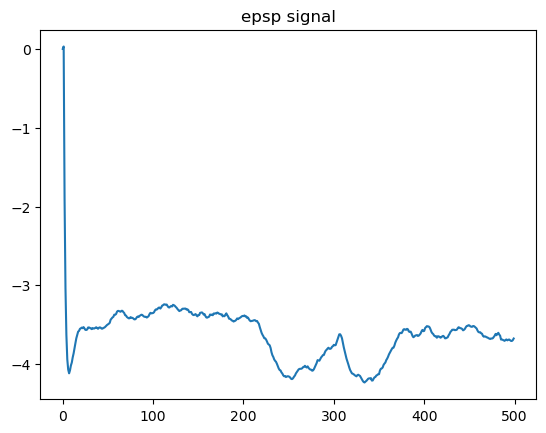

In [ ]:
# check out the epsp signal

plt.figure()
plt.plot(epsp.T)
plt.title('epsp signal')
plt.show()

In [ ]:
# spect calculation code in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


(500, 40)
(40,)
(500,)


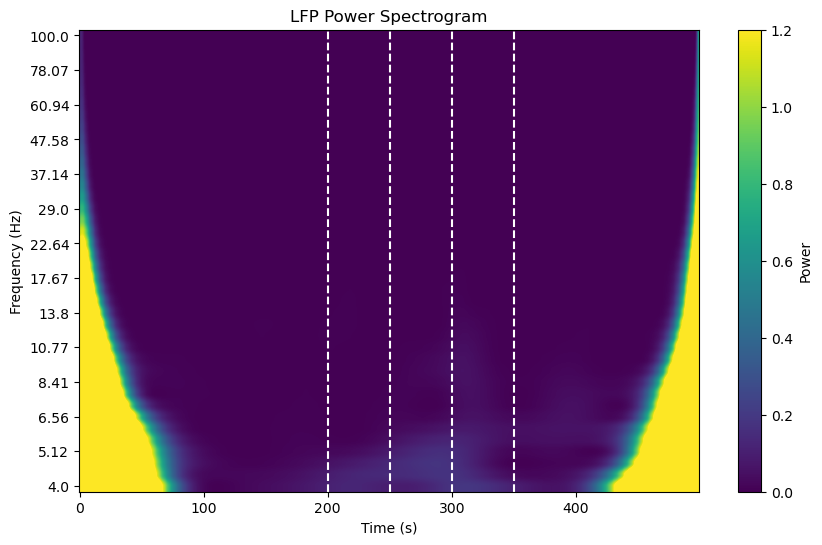

In [ ]:
# plot spect

power, freqs, lfp_power_z = compute_lfp_power_np(epsp, settings)
print(power.shape)
print(freqs.shape)
print(lfp_power_z.shape)

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
plt.axvline(x=settings['stim_on'], color='w', linestyle='--', label='Stim on')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'], color='w', linestyle='--', label='Stim off')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim on')
plt.axvline(x=settings['stim_on'] + 2*settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim off')
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()